In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

df = pd.read_csv("ai4i2020.csv")  
print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


FAILURE LABEL DISTRIBUTION
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure Rate: 3.39%


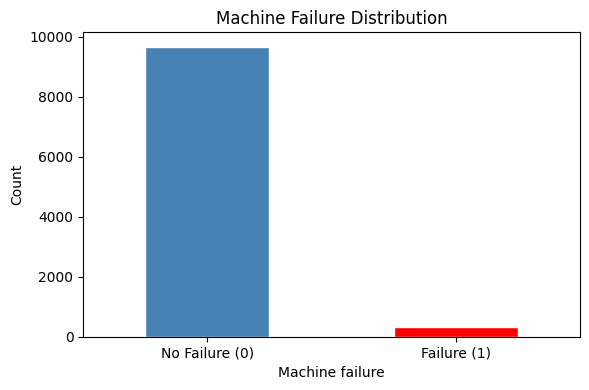

In [ ]:
# CELL 2 — Study Labels

print(df['Machine failure'].value_counts())
print(f"\nFailure Rate: {df['Machine failure'].mean() * 100:.2f}%")

plt.figure(figsize=(6, 4))
df['Machine failure'].value_counts().plot(kind='bar', color=['steelblue', 'red'], edgecolor='white')
plt.title('Machine Failure Distribution')
plt.xticks([0, 1], ['No Failure (0)', 'Failure (1)'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()


FAILURE TYPE BREAKDOWN
  Tool Wear                :   46 cases (0.46%)
  Heat Dissipation         :  115 cases (1.15%)
  Power                    :   95 cases (0.95%)
  Overstrain               :   98 cases (0.98%)
  Random                   :   19 cases (0.19%)


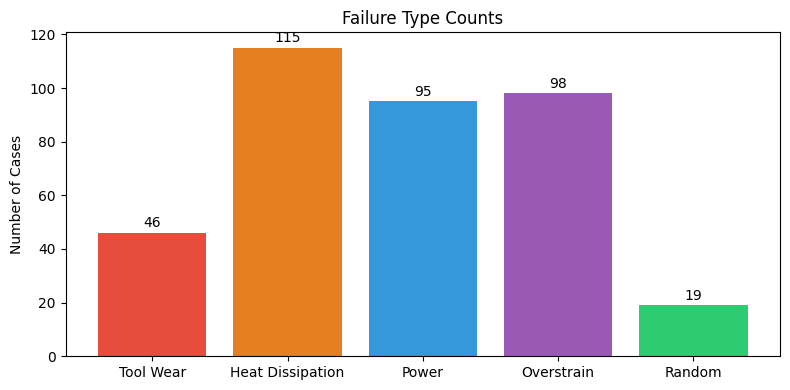

In [6]:
# CELL 3 — Analyze Failure Classes (TWF, HDF, PWF, OSF, RNF)
failure_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_names = ['Tool Wear', 'Heat Dissipation', 'Power', 'Overstrain', 'Random']

print("=" * 40)
print("FAILURE TYPE BREAKDOWN")
print("=" * 40)
for col, name in zip(failure_types, failure_names):
    count = df[col].sum()
    pct = count / len(df) * 100
    print(f"  {name:25s}: {count:4d} cases ({pct:.2f}%)")

plt.figure(figsize=(8, 4))
counts = [df[col].sum() for col in failure_types]
bars = plt.bar(failure_names, counts, color=['#e74c3c','#e67e22','#3498db','#9b59b6','#2ecc71'])
plt.title('Failure Type Counts')
plt.ylabel('Number of Cases')
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(count), ha='center', va='bottom', fontsize=10)
plt.tight_layout()


In [7]:
# CELL 4 — Statistics per failure type
print("=" * 40)
print("SENSOR STATS: FAILURE vs NORMAL")
print("=" * 40)
features = ['Air temperature [K]', 'Torque [Nm]',
            'Rotational speed [rpm]', 'Tool wear [min]']

for feature in features:
    normal_mean = df[df['Machine failure']==0][feature].mean()
    fail_mean   = df[df['Machine failure']==1][feature].mean()
    print(f"\n{feature}")
    print(f"  Normal mean : {normal_mean:.2f}")
    print(f"  Failure mean: {fail_mean:.2f}")
    print(f"  Difference  : {abs(fail_mean - normal_mean):.2f}")

SENSOR STATS: FAILURE vs NORMAL

Air temperature [K]
  Normal mean : 299.97
  Failure mean: 300.89
  Difference  : 0.91

Torque [Nm]
  Normal mean : 39.63
  Failure mean: 50.17
  Difference  : 10.54

Rotational speed [rpm]
  Normal mean : 1540.26
  Failure mean: 1496.49
  Difference  : 43.77

Tool wear [min]
  Normal mean : 106.69
  Failure mean: 143.78
  Difference  : 37.09


In [9]:
# CELL 5 — Export Failure Report
failure_summary = df[df['Machine failure']==1][failure_types].sum()

report = f"""# Failure Analysis Report

## Overview
- Total records: {len(df)}
- Total failures: {df['Machine failure'].sum()}
- Failure rate: {df['Machine failure'].mean()*100:.2f}%

## Failure Type Breakdown
| Type | Full Name | Count | % of Total |
|------|-----------|-------|-----------|
| TWF | Tool Wear Failure | {df['TWF'].sum()} | {df['TWF'].mean()*100:.2f}% |
| HDF | Heat Dissipation Failure | {df['HDF'].sum()} | {df['HDF'].mean()*100:.2f}% |
| PWF | Power Failure | {df['PWF'].sum()} | {df['PWF'].mean()*100:.2f}% |
| OSF | Overstrain Failure | {df['OSF'].sum()} | {df['OSF'].mean()*100:.2f}% |
| RNF | Random Failure | {df['RNF'].sum()} | {df['RNF'].mean()*100:.2f}% |

## Key Observations
- Dataset is highly imbalanced — only ~{df['Machine failure'].mean()*100:.1f}% failures
- Oversampling (SMOTE) will be needed in the modeling phase
- Heat Dissipation and Tool Wear are the most common failure modes
"""
with open('failure_report.md', 'w') as f:   
    f.write(report)


